Visual Data Analysis

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()
sns.set_context(
    "notebook",
    font_scale=1.5,
    rc={"figure.figsize": (11, 8), "axes.titlesize": 18}
)

from matplotlib import rcParams
rcParams["figure.figsize"] = (11, 8)


pd.set_option("display.max.columns", 100)

data = pd.read_csv("M:/accenture/ds-ml-training/ds-ai-assignments-maksym-bondar/weeks/week1/data/day.csv")  

In [4]:
print("Dataset size:", data.shape)

data.head()

Dataset size: (731, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
categorical_cols = [
    "season", # 4 fixed categories: spring, summer, fall, winter.
    "yr", # Only 0 or 1 (year 2011 or 2012), not a continuous measurement
    "mnth", # 1–12 month labels, ordered categories not continuous.
    "holiday", # Binary category (holiday vs non-holiday).
    "weekday", # 0–6 labels for days of week, not numeric measurements.
    "workingday", # Binary category: working day vs weekend/holiday.
    "weathersit" # Weather type categories (1–4: clear, mist, light rain, etc.)
]

numerical_cols = [
    "temp", "atemp", "hum", "windspeed",
    "casual", "registered", "cnt"
]

In [6]:
threshold = data["cnt"].median()
data["high_demand"] = (data["cnt"] > threshold).astype(int)

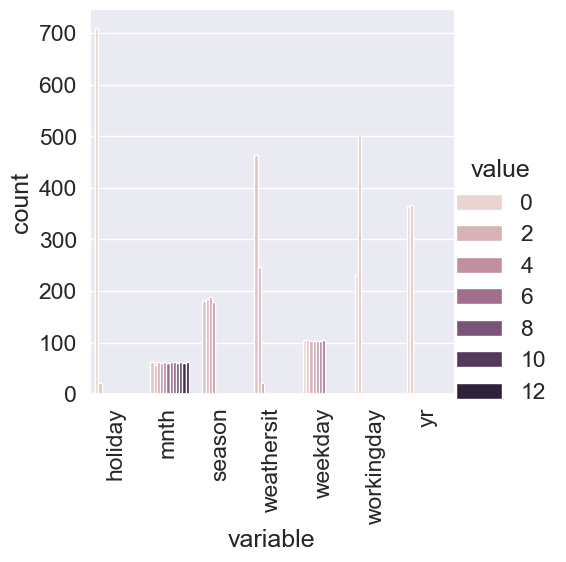

In [7]:
data_uniques = pd.melt(
    frame=data,
    value_vars=categorical_cols
)

data_uniques = (
    pd.DataFrame(data_uniques.groupby(["variable", "value"])["value"].count())
    .sort_index(level=[0, 1])
    .rename(columns={"value": "count"})
    .reset_index()
)

sns.catplot(
    x="variable",
    y="count",
    hue="value",
    data=data_uniques,
    kind="bar"
)

plt.xticks(rotation=90);

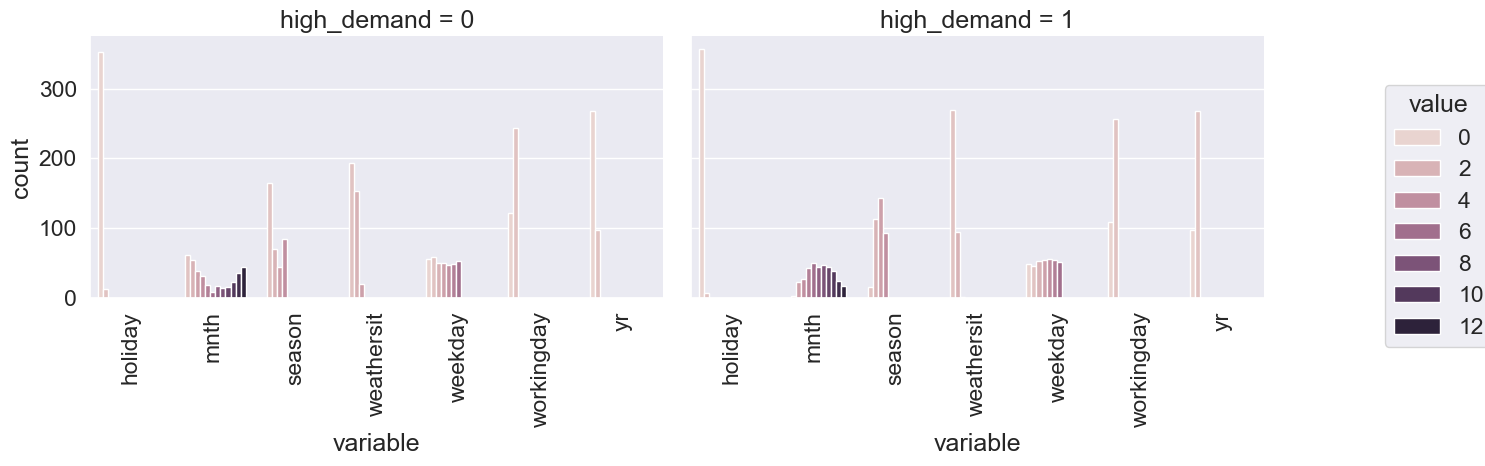

In [8]:
data_uniques = pd.melt(
    frame=data,
    value_vars=categorical_cols,
    id_vars=["high_demand"]
)

data_uniques = (
    pd.DataFrame(data_uniques.groupby(["variable", "value", "high_demand"])["value"].count())
    .rename(columns={"value": "count"})
    .reset_index()
)

g = sns.catplot(
    x="variable",
    y="count",
    hue="value",
    col="high_demand",
    data=data_uniques,
    kind="bar",
    height=5,
    aspect=1.2
)

# Rotate labels for all subplots
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# Move legend further right
g._legend.set_bbox_to_anchor((1.15, 0.5))  # (x offset, y offset)
g._legend.set_frame_on(True)

plt.tight_layout()


In [9]:
for c in data.columns:
    n = data[c].nunique()
    print(c)
    if n <= 10:
        print(n, sorted(data[c].value_counts().to_dict().items()))
    else:
        print(n)
    print("-" * 10)


instant
731
----------
dteday
731
----------
season
4 [(1, 181), (2, 184), (3, 188), (4, 178)]
----------
yr
2 [(0, 365), (1, 366)]
----------
mnth
12
----------
holiday
2 [(0, 710), (1, 21)]
----------
weekday
7 [(0, 105), (1, 105), (2, 104), (3, 104), (4, 104), (5, 104), (6, 105)]
----------
workingday
2 [(0, 231), (1, 500)]
----------
weathersit
3 [(1, 463), (2, 247), (3, 21)]
----------
temp
499
----------
atemp
690
----------
hum
595
----------
windspeed
650
----------
casual
606
----------
registered
679
----------
cnt
696
----------
high_demand
2 [(0, 366), (1, 365)]
----------


In [10]:
categorical_count = len(categorical_cols)
numerical_count = len(numerical_cols)

print("Categorical features ({}):".format(categorical_count))
for c in categorical_cols:
    print("  -", c)

print("\nNumerical features ({}):".format(numerical_count))
for c in numerical_cols:
    print("  -", c)

print("\nTotal rows:", data.shape[0])

Categorical features (7):
  - season
  - yr
  - mnth
  - holiday
  - weekday
  - workingday
  - weathersit

Numerical features (7):
  - temp
  - atemp
  - hum
  - windspeed
  - casual
  - registered
  - cnt

Total rows: 731


Part 1. Basic Observations 

1.1. How many working and non-working days are in the dataset?

In [11]:
data["workingday"].value_counts()

workingday
1    500
0    231
Name: count, dtype: int64

1.2. Which type of day has higher average bike demand: working days or non-working days?

In [12]:
data.groupby("workingday")["cnt"].mean()

workingday
0    4330.168831
1    4584.820000
Name: cnt, dtype: float64

1.3. What is the rounded difference in percentage points between the share of high-demand days for working vs non-working days?

In [13]:
share_work = data.loc[data["workingday"] == 1, "high_demand"].mean()
share_nonwork = data.loc[data["workingday"] == 0, "high_demand"].mean()

round(100 * (share_nonwork - share_work))

-4

working days have slightly more high-demand days

1.4. What is the rounded difference between median temperatures (in °C) for high-demand and low-demand days?

temp : Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)

In [14]:
t_min, t_max = -8, 39

median_high = data.loc[data["high_demand"] == 1, "temp"].median()
median_low  = data.loc[data["high_demand"] == 0, "temp"].median()

median_high_c = median_high * (t_max - t_min) + t_min
median_low_c  = median_low  * (t_max - t_min) + t_min

round(median_high_c - median_low_c)

12

high-demand days are warmer on average

1.2. Risk maps

the fraction of high-demand days in each group and their ratio: summer and workingdays

In [15]:
summer_work = data[(data["season"] == 3) & (data["workingday"] == 1)]

p_cool = summer_work[summer_work["temp"] < 0.4]["high_demand"].mean()
p_warm = summer_work[summer_work["temp"] >= 0.7]["high_demand"].mean()

ratio = p_warm / p_cool

p_cool, p_warm, ratio


(nan, np.float64(0.7951807228915663), np.float64(nan))

In [16]:
summer_work["temp"].describe()

count    131.000000
mean       0.706132
std        0.069989
min        0.469167
25%        0.665833
50%        0.716667
75%        0.751667
max        0.848333
Name: temp, dtype: float64

In [17]:
q25 = summer_work["temp"].quantile(0.25)
q75 = summer_work["temp"].quantile(0.75)

print("Cool threshold:", q25)
print("Warm threshold:", q75)

p_cool = summer_work[summer_work["temp"] < q25]["high_demand"].mean()
p_warm = summer_work[summer_work["temp"] >= q75]["high_demand"].mean()

ratio = p_warm / p_cool

p_cool, p_warm, ratio

Cool threshold: 0.665833
Warm threshold: 0.7516665


(np.float64(0.71875),
 np.float64(0.696969696969697),
 np.float64(0.9696969696969697))

Warm summer working days are slightly less likely to be high-demand compared to cool summer working day

1.3. Analyzing a new feature

utilization = cnt / (registered + 1e-6)

shows how many total rentals per registered user we see on a day

In [18]:
data["utilization"] = data["cnt"] / (data["registered"] + 1e-6)

In [19]:
data["utilization"].median()

np.float64(1.1747904906490865)

In [20]:
data.groupby("workingday")["utilization"].median()

workingday
0    1.466038
1    1.149218
Name: utilization, dtype: float64

In [21]:
data.groupby("high_demand")["utilization"].median()

high_demand
0    1.140086
1    1.193740
Name: utilization, dtype: float64

In [22]:
data.groupby(["workingday", "high_demand"])["utilization"].median()

workingday  high_demand
0           0              1.307349
            1              1.524883
1           0              1.101034
            1              1.171807
Name: utilization, dtype: float64

the difference between high and low demand is stronger on weekends

1.4. Cleaning data

humidity outside [2.5%, 97.5%] percentiles

windspeed outside [2.5%, 97.5%] percentiles

cnt outside [2.5%, 97.5%] percentiles

humidity can be wrongly recorded (0 or >1)

windspeed often has strange zeros due to missing values in original dataset

cnt might have very low or very high values that distort analysis

In [23]:
to_remove = data[
    (data["hum"]       < data["hum"].quantile(0.025)) |
    (data["hum"]       > data["hum"].quantile(0.975)) |
    (data["windspeed"] < data["windspeed"].quantile(0.025)) |
    (data["windspeed"] > data["windspeed"].quantile(0.975)) |
    (data["cnt"]       < data["cnt"].quantile(0.025)) |
    (data["cnt"]       > data["cnt"].quantile(0.975))
]

removed_share = to_remove.shape[0] / data.shape[0]
removed_share

0.15047879616963064

In [24]:
filtered_data = data[~data.index.isin(to_remove.index)]
filtered_data.shape

(621, 18)

Part 2. Visual data analysis

In [25]:
df = filtered_data.copy()

2.2. Distribution of rentals for working vs non-working days

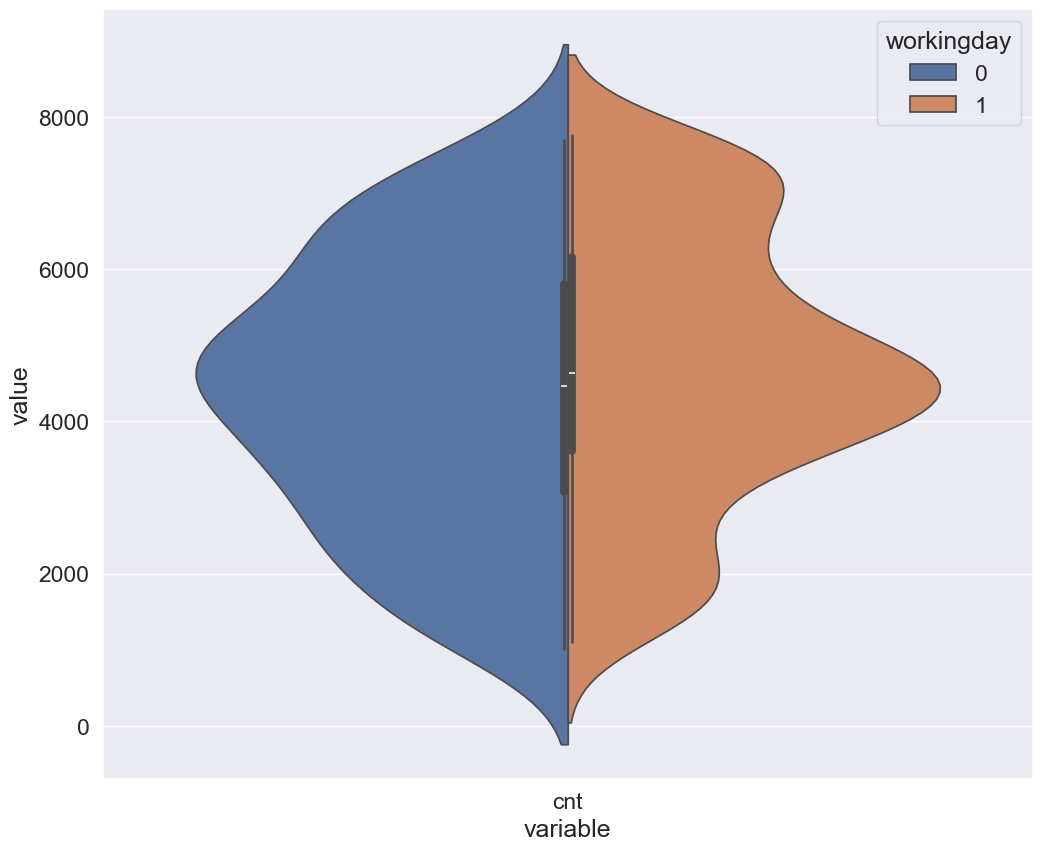

In [26]:
df_melt = pd.melt(frame=df, value_vars=["cnt"], id_vars=["workingday"])

plt.figure(figsize=(12, 10))
sns.violinplot(
    x="variable",
    y="value",
    hue="workingday",
    data=df_melt,
    split=True,
    scale="count",
    scale_hue=False
)
plt.show()

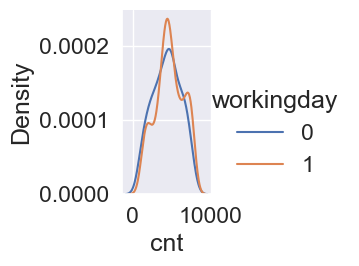

In [27]:
sns.FacetGrid(df, hue="workingday").map(sns.kdeplot, "cnt").add_legend()
plt.show()

2.3. Rank correlation

In [28]:
num_cols = [
    "temp", "atemp", "hum", "windspeed",
    "casual", "registered", "cnt"
]

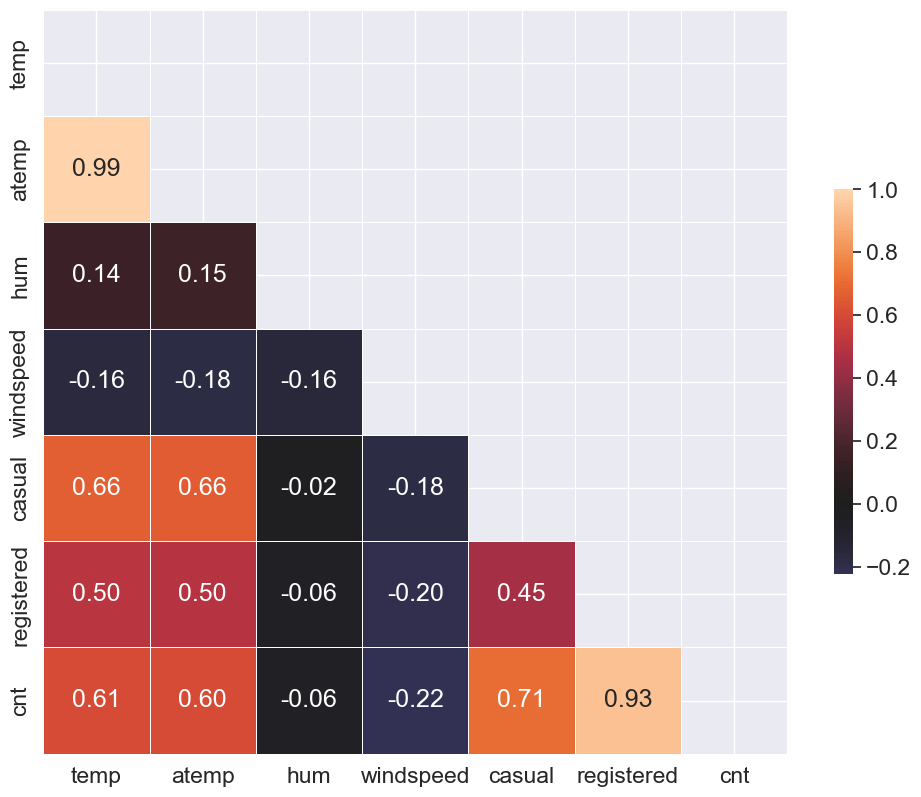

In [29]:
corr_spear = df[num_cols].corr(method="spearman")

mask = np.zeros_like(corr_spear, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_spear,
    mask=mask,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5}
)
plt.show()

2.4. Month vs high demand

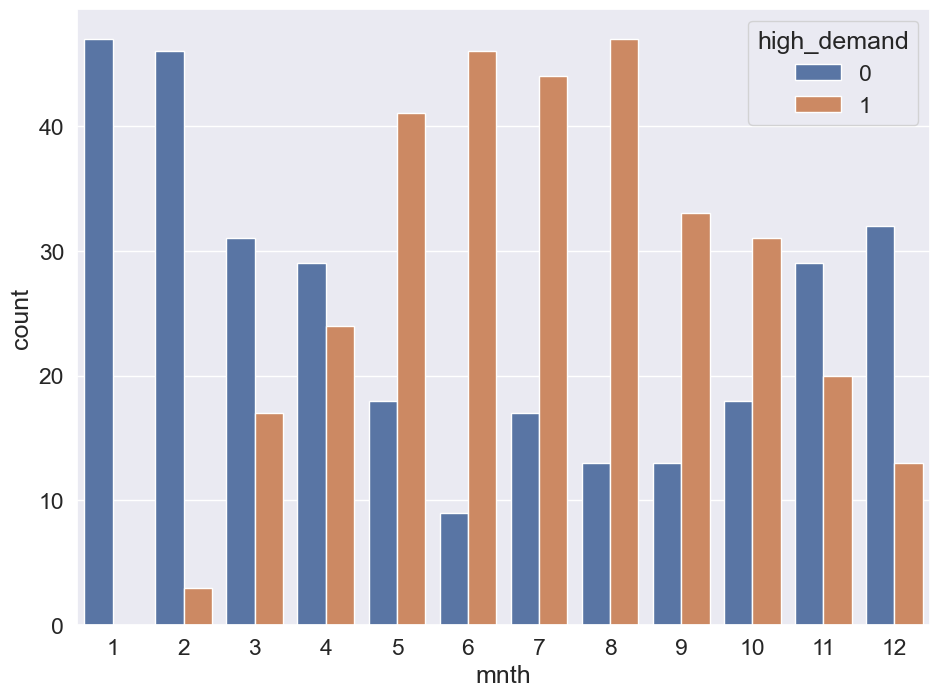

In [30]:
sns.countplot(x="mnth", hue="high_demand", data=df)
plt.show()